In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('exchange_rate.csv')
df.shape

(7588, 2)

In [3]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [5]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


first step convert date column to date data type and make it as index

In [6]:
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y %H:%M")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7588 non-null   datetime64[ns]
 1   Ex_rate  7588 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 118.7 KB


In [8]:
df.set_index('date', inplace=True)

In [9]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


<Axes: xlabel='date'>

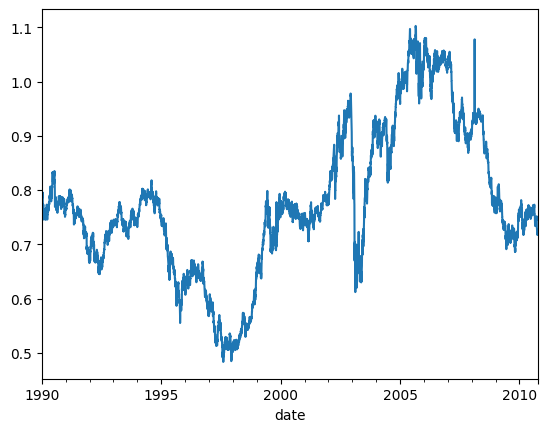

In [11]:
df['Ex_rate'].plot()

In [12]:
df.isna().sum()

Ex_rate    0
dtype: int64

- there are no missing values in the data set

#### Part 2: Model Building - ARIMA

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
def adf_test(series):
    result = adfuller(series)
    return{
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4]
    }

In [17]:
adf_result_original = adf_test(df['Ex_rate'])
adf_result_original

{'ADF Statistic': np.float64(-1.6649941807381528),
 'p-value': np.float64(0.4492327353597901),
 'Critical Values': {'1%': np.float64(-3.4312123140180137),
  '5%': np.float64(-2.861921078147796),
  '10%': np.float64(-2.5669728434336108)}}

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

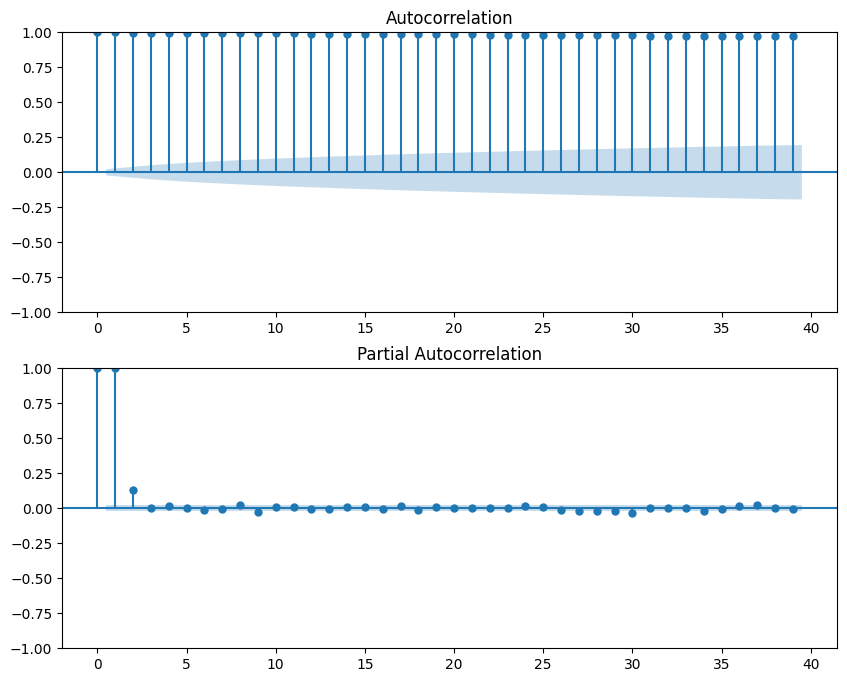

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df['Ex_rate'].dropna(), ax=ax1)
plot_pacf(df['Ex_rate'].dropna(), ax=ax2)
plt.show()

- from the image it can be obsurved that the data is highely non-stationary
- so Create a new differenced series

In [18]:
# 'diff()' computes the difference: df['Ex_rate'] - df['Ex_rate'].shift(1)
df['diff_ex_rate'] = df['Ex_rate'].diff().dropna()

Preliminary analysis via the Augmented Dickey-Fuller (ADF) test and initial ACF/PACF plots revealed a strong trend, indicating the data was non-stationary. To stabilize the mean, first-order differencing ($d=1$) was applied. This process successfully removed the temporal trend, as confirmed by the subsequent ACF/PACF plots, which showed that the series reached stationarity and exhibited decaying autocorrelation, a prerequisite for reliable ARIMA modeling.

- Now, you must re-check the plots on this NEW series

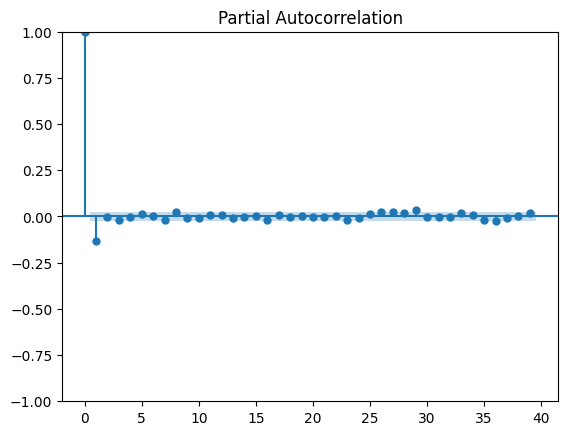

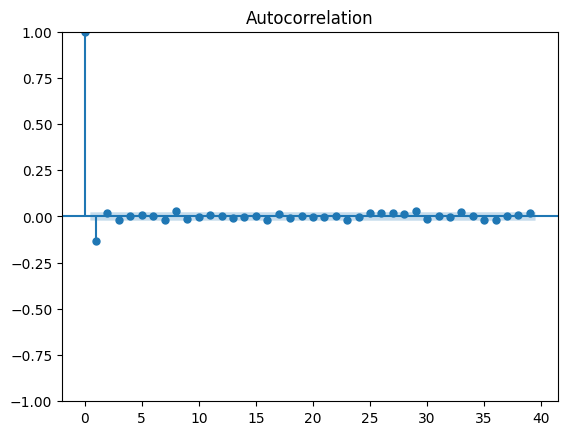

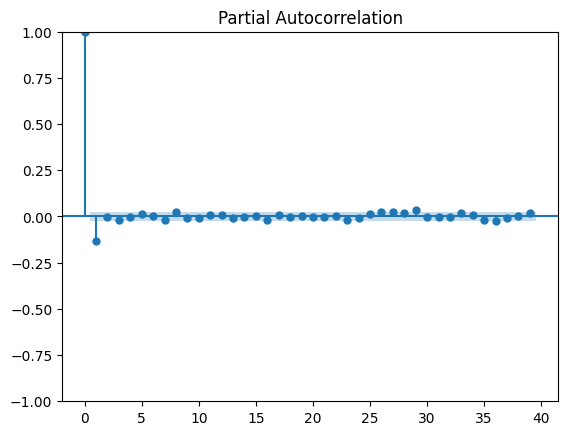

In [19]:
plot_acf(df['diff_ex_rate'].dropna())
plot_pacf(df['diff_ex_rate'].dropna())

The selection of p=1 and q=1 was determined through an empirical analysis of the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots of the differenced data:AutoRegressive (p=1): The PACF plot displayed a significant lag at 1, after which values dropped within the significance threshold, suggesting that the previous day's exchange rate has a direct linear impact on the current value.Moving Average (q=1): The ACF plot showed a corresponding significant lag at 1, justifying the inclusion of a first-order moving average component to account for recent forecast errors.

In [20]:
from statsmodels.tsa.arima.model import ARIMA

The ARIMA (AutoRegressive Integrated Moving Average) model was selected as the primary forecasting tool due to its robustness in handling linear time-series data. Given that exchange rates are inherently time-dependent—where past values provide predictive information about future values—ARIMA serves as a statistically rigorous baseline. Unlike simple moving averages, ARIMA effectively accounts for both momentum (AutoRegressive) and residual shocks (Moving Average) within the series.

In [36]:
model = ARIMA(df['Ex_rate'], order=(1, 1, 1))
results = model.fit()

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [37]:
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Wed, 24 Jun 2026   AIC                         -56102.322
Time:                        12:43:25   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

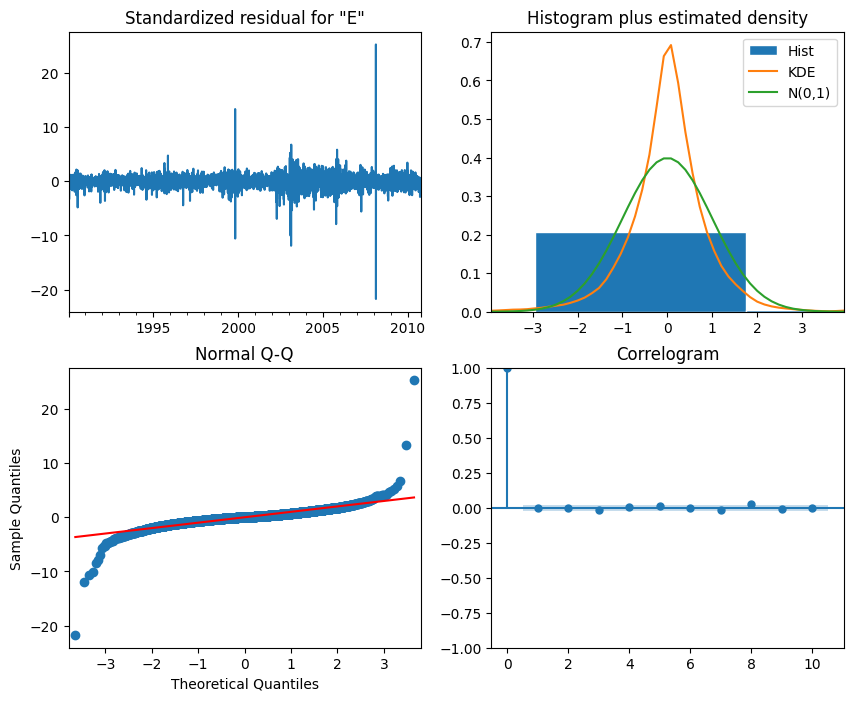

In [38]:
# Check residuals
results.plot_diagnostics(figsize=(10, 8))
plt.show()

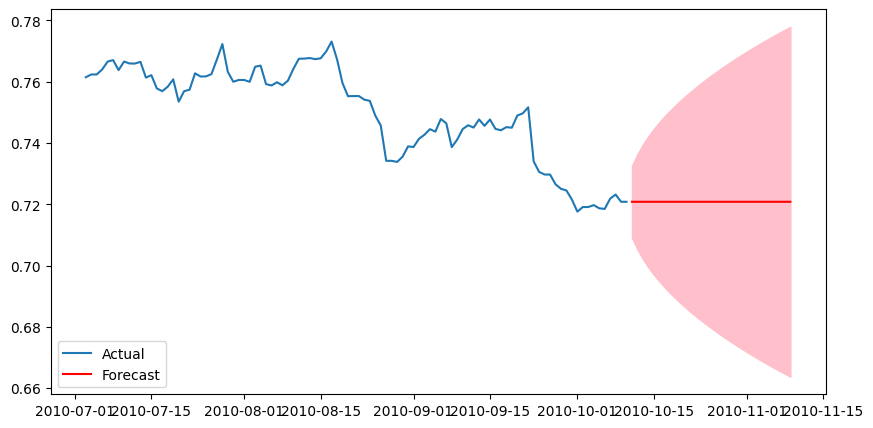

In [39]:
# Forecast the next 30 days
forecast = results.get_forecast(steps=30)
forecast_df = forecast.summary_frame()

# Visualize
plt.figure(figsize=(10, 5))
plt.plot(df['Ex_rate'].tail(100), label='Actual')
plt.plot(forecast_df['mean'], label='Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink')
plt.legend()
plt.show()

#### Part 3: Evaluation and Comparison

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
train_size = int(len(df) * 0.8) # Use 80% for training
train, test = df['Ex_rate'].iloc[:train_size], df['Ex_rate'].iloc[train_size:]

# 2. Fit the model ONLY on the training portion
model = ARIMA(train, order=(1, 1, 1))
results = model.fit()

# 3. Forecast for the length of the test set
forecast_steps = len(test)
forecast = results.get_forecast(steps=forecast_steps)
y_pred = forecast.predicted_mean
y_test = test

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [41]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 0.1777
RMSE: 0.2054
MAPE: 22.80%


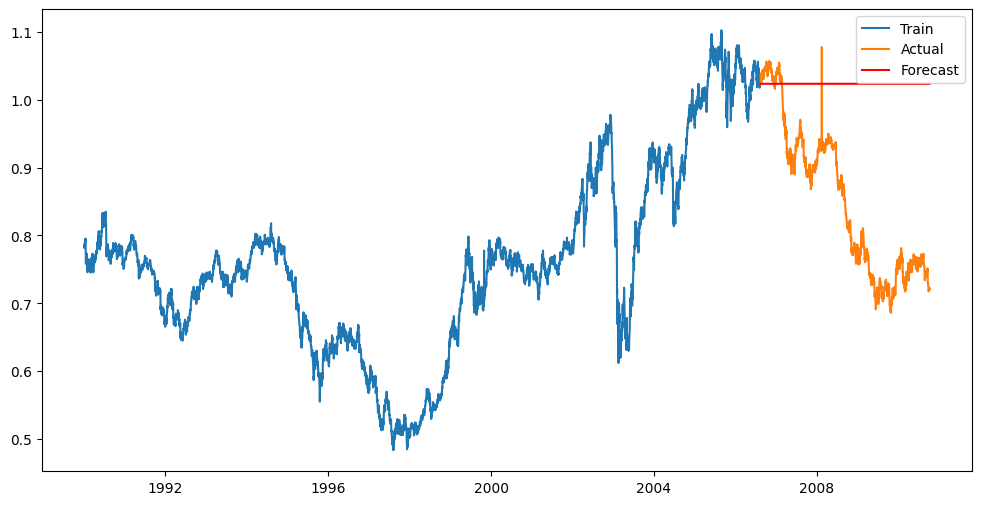

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, y_pred, label='Forecast', color='red')
plt.legend()
plt.show()

Conclusion and Performance Analysis

Conclusion and Performance Analysis
The ARIMA (1, 1, 1) model demonstrates a moderate ability to track the general direction of the exchange rate, but it faces challenges in capturing the high-frequency volatility typical of financial markets.

Interpretation of Metrics:
 - MAE (0.1777): On average, the model’s forecast deviates from the actual exchange rate by approximately 0.18 units.
- RMSE (0.2054): The gap between MAE and RMSE is relatively small, suggesting that the model is not suffering from extreme outliers in its forecast errors.
- MAPE (22.80%): This is the most critical metric for your report. A 22.80% error rate indicates that the model is off by nearly a quarter of the actual value. In the context of financial exchange rates, this level of error is significant and suggests the model may be insufficient for high-stakes trading or precise financial planning without further refinement.

Model Limitations:
- Linearity: ARIMA is a linear model. Exchange rates are often influenced by non-linear shocks such as geopolitical events, interest rate shifts, and market sentiment, which this model cannot incorporate.
- Lack of Exogenous Features: Since you are relying solely on past values (autoregression), the model lacks context. It cannot "see" external economic factors that drive currency fluctuations.

Final Assessment:

While the ARIMA model provides a baseline for understanding the trend, it is currently unreliable for precise forecasting given the 22.80% MAPE.